# BrainScanAI — Exploration initiale du jeu de données

## Objectifs

Cette première analyse vise à :

- examiner la structure des fichiers ;
- identifier les images et les fichiers de métadonnées ;
- mesurer le volume du dataset ;
- vérifier les formats, résolutions et canaux de couleur ;
- détecter les images illisibles ou incohérentes ;
- afficher un échantillon représentatif des radiographies.

Aucun modèle de Machine Learning n'est entraîné à cette étape.

## 1. Imports et configuration

Cette section importe les bibliothèques nécessaires à l'exploration du
dataset et configure une graine aléatoire afin de rendre les
échantillonnages reproductibles.

In [22]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision

from PIL import Image, UnidentifiedImageError
from IPython.display import display
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

mps_available = (
    hasattr(torch.backends, "mps")
    and torch.backends.mps.is_available()
)

print(f"PyTorch : {torch.__version__}")
print(f"Torchvision : {torchvision.__version__}")
print(f"Accélération Apple MPS disponible : {mps_available}")
print("Imports réussis.")

PyTorch : 2.13.0
Torchvision : 0.28.0
Accélération Apple MPS disponible : True
Imports réussis.


## 2. Localisation du dataset

Le notebook identifie automatiquement la racine du projet grâce au
fichier `pyproject.toml`. Cette méthode permet d'exécuter le notebook
depuis la racine du projet ou depuis le dossier `notebooks`.

In [23]:
def trouver_racine_projet(repertoire_depart: Path) -> Path:
    """
    Recherche le dossier du projet contenant pyproject.toml.
    """

    candidats = (
        repertoire_depart,
        *repertoire_depart.parents,
    )

    for candidat in candidats:
        if (candidat / "pyproject.toml").exists():
            return candidat

    raise FileNotFoundError(
        "Impossible de trouver la racine du projet."
    )


CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = trouver_racine_projet(CURRENT_DIR)

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

DATASET_DIR = (
    RAW_DATA_DIR
    / "mri_dataset_brain_cancer_oc"
)

LABELED_DIR = DATASET_DIR / "avec_labels"
CANCER_DIR = LABELED_DIR / "cancer"
NORMAL_DIR = LABELED_DIR / "normal"
UNLABELED_DIR = DATASET_DIR / "sans_label"

print(f"Répertoire courant : {CURRENT_DIR}")
print(f"Racine du projet : {PROJECT_ROOT}")
print(f"Dataset : {DATASET_DIR}")
print()

print(f"Dataset présent : {DATASET_DIR.exists()}")
print(f"Dossier cancer présent : {CANCER_DIR.exists()}")
print(f"Dossier normal présent : {NORMAL_DIR.exists()}")
print(f"Dossier sans label présent : {UNLABELED_DIR.exists()}")

Répertoire courant : /Users/vincentdesmouceaux/dev/BrainScanAI/notebooks
Racine du projet : /Users/vincentdesmouceaux/dev/BrainScanAI
Dataset : /Users/vincentdesmouceaux/dev/BrainScanAI/data/raw/mri_dataset_brain_cancer_oc

Dataset présent : True
Dossier cancer présent : True
Dossier normal présent : True
Dossier sans label présent : True


## 3. Structure du dataset

Le dataset est séparé entre les images disposant d'un label expert et
les images non annotées.

Les labels disponibles sont :

- `cancer` ;
- `normal`.

Les images non annotées se trouvent dans le dossier `sans_label`.

In [24]:
def afficher_structure(repertoire: Path) -> None:
    """
    Affiche uniquement les dossiers et les fichiers situés
    directement à la racine du dataset.
    """

    if not repertoire.exists():
        print(f"Dossier introuvable : {repertoire}")
        return

    print(f"[DOSSIER] {repertoire.name}")

    for chemin in sorted(repertoire.rglob("*")):
        if chemin.is_dir():
            profondeur = len(
                chemin.relative_to(repertoire).parts
            )

            indentation = "    " * profondeur

            print(
                f"{indentation}[DOSSIER] {chemin.name}"
            )

    print("\nDocuments présents à la racine :")

    for chemin in sorted(repertoire.iterdir()):
        if chemin.is_file():
            print(f"- {chemin.name}")


afficher_structure(DATASET_DIR)

[DOSSIER] mri_dataset_brain_cancer_oc
    [DOSSIER] avec_labels
        [DOSSIER] cancer
        [DOSSIER] normal
    [DOSSIER] sans_label

Documents présents à la racine :
- Jeu de Données d'Images Cérébrales pour la Détection de Tumeurs.txt


In [25]:
documentation_paths = sorted(
    DATASET_DIR.glob("*.txt")
)

print(
    f"Nombre de fichiers de documentation : "
    f"{len(documentation_paths)}"
)

for documentation_path in documentation_paths:
    print("\n" + "=" * 80)
    print(f"DOCUMENT : {documentation_path.name}")
    print("=" * 80)

    contenu = documentation_path.read_text(
        encoding="utf-8",
        errors="replace",
    )

    print(contenu[:5_000])

Nombre de fichiers de documentation : 1

DOCUMENT : Jeu de Données d'Images Cérébrales pour la Détection de Tumeurs.txt
Description

Ce jeu de données comprend un total de 1500 images :

    1400 images non étiquetées

    100 images étiquetées

Les images étiquetées sont réparties en deux catégories :

    Normal : Images de cerveaux sains.

    Cancer : Images de cerveaux présentant des signes de tumeurs.

Caractéristiques des Images

Toutes les images ont été redimensionnées à une taille standardisée de 512×512 pixels. Cette standardisation assure leur compatibilité avec divers pipelines de traitement d'images et d'apprentissage automatique. Elles sont enregistrées au format d'image courant JPEG (.jpg).
Applications Potentielles

Ce jeu de données peut être exploité pour un large éventail d'applications, notamment :

    🤖 L'entraînement et l'évaluation de divers modèles d'apprentissage profond (par exemple, DenseNet201, YOLOv8x/s, CNN, ResNet50v2, VGG-16, MobileNetV2).

    🔬 Le dé

## 4. Inventaire des images

Cette section recense toutes les images sans encore charger leurs
pixels en mémoire.

Chaque fichier est associé à sa catégorie et, lorsque l'information est
disponible, à son label expert.

In [26]:
EXTENSIONS_IMAGES = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
}

image_paths = sorted(
    chemin
    for chemin in DATASET_DIR.rglob("*")
    if chemin.is_file()
    and chemin.suffix.lower() in EXTENSIONS_IMAGES
)

print(f"Nombre total d'images : {len(image_paths)}")

Nombre total d'images : 1506


In [27]:
def identifier_categorie_et_label(
    image_path: Path,
) -> tuple[str, str | None]:
    """
    Détermine la catégorie et le label à partir du dossier
    contenant l'image.
    """

    dossier_parent = image_path.parent.name.lower()

    if dossier_parent == "cancer":
        return "cancer", "cancer"

    if dossier_parent == "normal":
        return "normal", "normal"

    if dossier_parent == "sans_label":
        return "sans_label", None

    return "inconnue", None

In [28]:
image_records = []

for image_path in image_paths:
    categorie, label = identifier_categorie_et_label(
        image_path
    )

    image_records.append(
        {
            "path": str(image_path),
            "chemin_relatif": str(
                image_path.relative_to(PROJECT_ROOT)
            ),
            "nom_fichier": image_path.name,
            "extension": image_path.suffix.lower(),
            "categorie": categorie,
            "label": label,
            "taille_fichier_ko": round(
                image_path.stat().st_size / 1024,
                2,
            ),
        }
    )

df_images = pd.DataFrame(image_records)

display(df_images.head())

,path,chemin_relatif,nom_fichier,extension,categorie,label,taille_fichier_ko
0,/Users/vincentdesmouceaux/dev/BrainScanAI/data...,data/raw/mri_dataset_brain_cancer_oc/avec_labe...,05340cd4-3bb2-459d-9937-bf27d52d8351.jpg,.jpg,cancer,cancer,25.24
1,/Users/vincentdesmouceaux/dev/BrainScanAI/data...,data/raw/mri_dataset_brain_cancer_oc/avec_labe...,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,.jpg,cancer,cancer,17.66
2,/Users/vincentdesmouceaux/dev/BrainScanAI/data...,data/raw/mri_dataset_brain_cancer_oc/avec_labe...,0f718241-8f63-4b55-81ce-315324b51069.jpg,.jpg,cancer,cancer,17.69
3,/Users/vincentdesmouceaux/dev/BrainScanAI/data...,data/raw/mri_dataset_brain_cancer_oc/avec_labe...,11a7a426-4806-401e-98b2-b96e7094d1a6.jpg,.jpg,cancer,cancer,24.04
4,/Users/vincentdesmouceaux/dev/BrainScanAI/data...,data/raw/mri_dataset_brain_cancer_oc/avec_labe...,1c043dbb-4623-4769-8e5e-0223bd745040.jpg,.jpg,cancer,cancer,24.14


In [29]:
repartition_categories = (
    df_images["categorie"]
    .value_counts()
    .rename_axis("categorie")
    .reset_index(name="nombre_images")
)

display(repartition_categories)

,categorie,nombre_images
0,sans_label,1406
1,cancer,50
2,normal,50


In [30]:
nombre_annotees = df_images["label"].notna().sum()
nombre_non_annotees = df_images["label"].isna().sum()
nombre_total = len(df_images)

pourcentage_annote = (
    nombre_annotees / nombre_total * 100
)

print(f"Nombre total d'images : {nombre_total}")
print(f"Images annotées : {nombre_annotees}")
print(f"Images sans label : {nombre_non_annotees}")
print(
    f"Part annotée du dataset : "
    f"{pourcentage_annote:.2f} %"
)

Nombre total d'images : 1506
Images annotées : 100
Images sans label : 1406
Part annotée du dataset : 6.64 %


In [31]:
repartition_extensions = (
    df_images["extension"]
    .value_counts()
    .rename_axis("extension")
    .reset_index(name="nombre_images")
)

display(repartition_extensions)

,extension,nombre_images
0,.jpg,1506


## 5. Constitution d'un échantillon de travail

Pour cette première exploration approfondie, un échantillon réduit est
constitué afin de limiter le temps de chargement.

L'échantillon conserve toutes les images annotées disponibles et ajoute
un sous-ensemble reproductible d'images sans label.

In [32]:
taille_par_categorie = {
    "cancer": 50,
    "normal": 50,
    "sans_label": 100,
}

echantillons = []

for categorie, taille_maximale in taille_par_categorie.items():
    groupe = df_images[
        df_images["categorie"] == categorie
    ]

    taille = min(
        taille_maximale,
        len(groupe),
    )

    echantillon_categorie = groupe.sample(
        n=taille,
        random_state=RANDOM_STATE,
    )

    echantillons.append(echantillon_categorie)

df_sample = pd.concat(
    echantillons,
    ignore_index=True,
)

df_sample = df_sample.sample(
    frac=1,
    random_state=RANDOM_STATE,
).reset_index(drop=True)

print(
    f"Taille de l'échantillon : "
    f"{len(df_sample)} images"
)

display(
    df_sample["categorie"]
    .value_counts()
    .rename_axis("categorie")
    .reset_index(name="nombre_images")
)

Taille de l'échantillon : 200 images


,categorie,nombre_images
0,sans_label,100
1,normal,50
2,cancer,50


## 6. Analyse technique des images

Pour chaque image de l'échantillon, les informations suivantes sont
extraites :

- format réel ;
- largeur et hauteur ;
- résolution ;
- mode de couleur ;
- nombre de canaux ;
- type des pixels ;
- intensité moyenne ;
- contraste approximatif ;
- validité du fichier.

In [33]:
def analyser_image(image_path: str) -> dict:
    """
    Extrait les principales caractéristiques techniques
    d'une image.
    """

    resultat = {
        "path": image_path,
        "valide": False,
        "format_image": None,
        "largeur": np.nan,
        "hauteur": np.nan,
        "resolution": None,
        "mode_couleur": None,
        "nombre_canaux": np.nan,
        "bandes": None,
        "type_pixels": None,
        "intensite_min": np.nan,
        "intensite_max": np.nan,
        "intensite_moyenne": np.nan,
        "ecart_type_pixels": np.nan,
        "erreur": None,
    }

    try:
        with Image.open(image_path) as image:
            # Force le chargement réel des pixels.
            image.load()

            largeur, hauteur = image.size
            bandes = image.getbands()

            image_grise = image.convert("L")

            pixels_gris = np.asarray(
                image_grise,
                dtype=np.float32,
            )

            pixels_originaux = np.asarray(image)

            resultat.update(
                {
                    "valide": True,
                    "format_image": image.format,
                    "largeur": largeur,
                    "hauteur": hauteur,
                    "resolution": (
                        f"{largeur} × {hauteur}"
                    ),
                    "mode_couleur": image.mode,
                    "nombre_canaux": len(bandes),
                    "bandes": ", ".join(bandes),
                    "type_pixels": str(
                        pixels_originaux.dtype
                    ),
                    "intensite_min": float(
                        pixels_gris.min()
                    ),
                    "intensite_max": float(
                        pixels_gris.max()
                    ),
                    "intensite_moyenne": float(
                        pixels_gris.mean()
                    ),
                    "ecart_type_pixels": float(
                        pixels_gris.std()
                    ),
                }
            )

    except (
        UnidentifiedImageError,
        OSError,
        ValueError,
    ) as erreur:
        resultat["erreur"] = str(erreur)

    return resultat

In [34]:
metadata_records = [
    analyser_image(image_path)
    for image_path in df_sample["path"]
]

df_metadata = pd.DataFrame(metadata_records)

df_exploration = df_sample.merge(
    df_metadata,
    on="path",
    how="left",
)

display(
    df_exploration[
        [
            "nom_fichier",
            "categorie",
            "format_image",
            "resolution",
            "mode_couleur",
            "nombre_canaux",
            "type_pixels",
            "valide",
        ]
    ].head(10)
)

,nom_fichier,categorie,format_image,resolution,mode_couleur,nombre_canaux,type_pixels,valide
0,2593c9b2-36d5-433b-81bf-44ab993a795e.jpg,normal,JPEG,512 × 512,RGB,3,uint8,True
1,2b810835-844c-49ff-b0f1-c7a71a0c696c.jpg,cancer,JPEG,512 × 512,RGB,3,uint8,True
2,b6a41ca0-aeea-43a8-b629-7c433cf03143.jpg,cancer,JPEG,512 × 512,RGB,3,uint8,True
3,2e039f72-ee1f-4bef-a7ee-ac814fb510b6.jpg,sans_label,JPEG,512 × 512,RGB,3,uint8,True
4,278518df-2894-4e70-8a6f-96d47064ee24.jpg,sans_label,JPEG,512 × 512,RGB,3,uint8,True
5,b3cc2a2a-c893-4007-8923-cf388e074e98.jpg,sans_label,JPEG,512 × 512,RGB,3,uint8,True
6,42ba7707-26c1-42bc-a00f-3d456741ef96.jpg,normal,JPEG,512 × 512,RGB,3,uint8,True
7,b6bc5e43-545c-4ad1-999a-fd8134cd462f.jpg,sans_label,JPEG,512 × 512,RGB,3,uint8,True
8,895361c0-ffa8-4152-b0d0-53935ac35a88.jpg,sans_label,JPEG,512 × 512,RGB,3,uint8,True
9,2d662cc1-509b-4657-a208-6d181aedd5e3.jpg,cancer,JPEG,512 × 512,RGB,3,uint8,True


In [35]:
nombre_valides = int(
    df_exploration["valide"].sum()
)

nombre_invalides = int(
    (~df_exploration["valide"]).sum()
)

print(
    f"Images valides dans l'échantillon : "
    f"{nombre_valides}"
)

print(
    f"Images invalides dans l'échantillon : "
    f"{nombre_invalides}"
)

Images valides dans l'échantillon : 200
Images invalides dans l'échantillon : 0


In [36]:
resolutions = (
    df_exploration[
        df_exploration["valide"]
    ]["resolution"]
    .value_counts()
    .rename_axis("resolution")
    .reset_index(name="nombre_images")
)

display(resolutions.head(20))

,resolution,nombre_images
0,512 × 512,200


In [37]:
modes_couleur = (
    df_exploration[
        df_exploration["valide"]
    ]["mode_couleur"]
    .value_counts()
    .rename_axis("mode_couleur")
    .reset_index(name="nombre_images")
)

display(modes_couleur)

,mode_couleur,nombre_images
0,RGB,200


In [38]:
canaux = (
    df_exploration[
        df_exploration["valide"]
    ]["nombre_canaux"]
    .value_counts()
    .rename_axis("nombre_canaux")
    .reset_index(name="nombre_images")
)

display(canaux)

,nombre_canaux,nombre_images
0,3,200


In [39]:
formats = (
    df_exploration[
        df_exploration["valide"]
    ]["format_image"]
    .value_counts()
    .rename_axis("format_image")
    .reset_index(name="nombre_images")
)

display(formats)

,format_image,nombre_images
0,JPEG,200


## 7. Exploration visuelle

Des images sont affichées pour chaque catégorie afin d'examiner
visuellement la diversité du dataset.

Cette observation reste purement exploratoire et ne constitue pas une
interprétation ou un diagnostic médical.

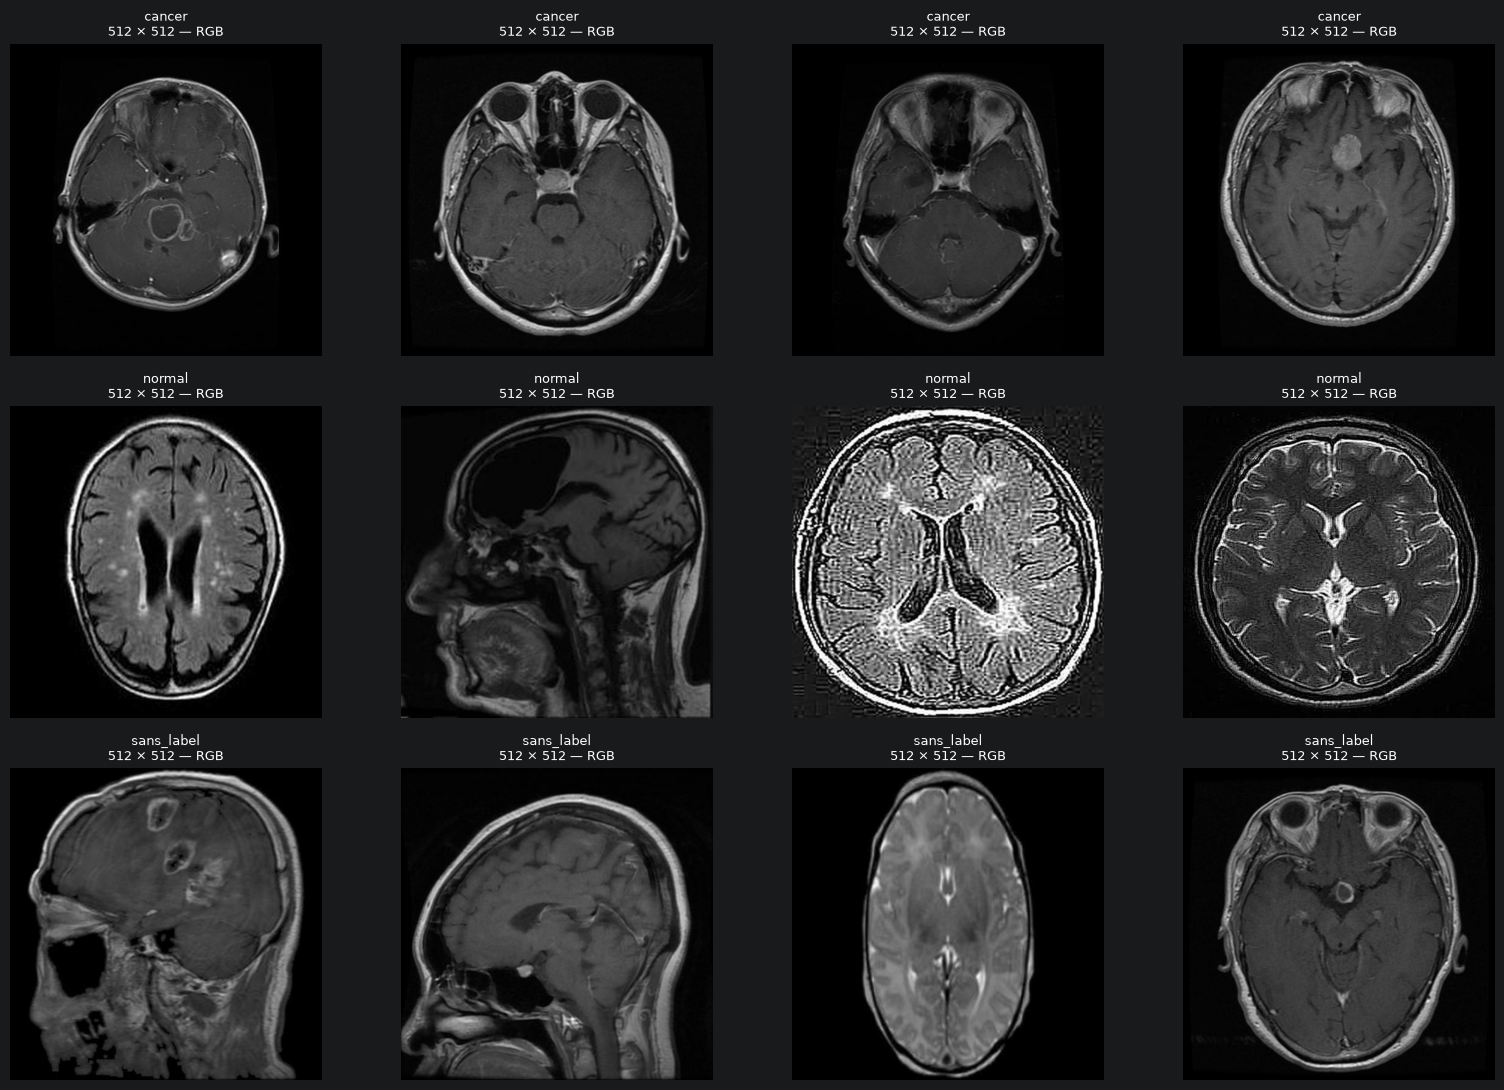

In [40]:
def afficher_exemples(
    dataframe: pd.DataFrame,
    nombre_par_categorie: int = 4,
) -> None:
    """
    Affiche des exemples pour les catégories cancer,
    normal et sans_label.
    """

    categories = [
        "cancer",
        "normal",
        "sans_label",
    ]

    figure, axes = plt.subplots(
        nrows=len(categories),
        ncols=nombre_par_categorie,
        figsize=(16, 11),
        squeeze=False,
    )

    for ligne, categorie in enumerate(categories):
        groupe = dataframe[
            dataframe["categorie"] == categorie
        ]

        nombre = min(
            nombre_par_categorie,
            len(groupe),
        )

        selection = groupe.sample(
            n=nombre,
            random_state=RANDOM_STATE,
        )

        for colonne in range(nombre_par_categorie):
            axe = axes[ligne, colonne]
            axe.axis("off")

            if colonne >= nombre:
                continue

            observation = selection.iloc[colonne]
            image_path = observation["path"]

            try:
                with Image.open(image_path) as image:
                    image.load()
                    tableau_pixels = np.asarray(image)

                    if image.mode in {
                        "1",
                        "L",
                        "I",
                        "I;16",
                        "F",
                    }:
                        axe.imshow(
                            tableau_pixels,
                            cmap="gray",
                        )
                    else:
                        axe.imshow(tableau_pixels)

                    axe.set_title(
                        f"{categorie}\n"
                        f"{image.width} × {image.height}"
                        f" — {image.mode}",
                        fontsize=9,
                    )

            except (
                UnidentifiedImageError,
                OSError,
                ValueError,
            ) as erreur:
                axe.text(
                    0.5,
                    0.5,
                    f"Image illisible\n{erreur}",
                    ha="center",
                    va="center",
                )

    plt.tight_layout()
    plt.show()


afficher_exemples(df_exploration)

In [41]:
images_faible_variation = (
    df_exploration[
        df_exploration["valide"]
        & (
            df_exploration[
                "ecart_type_pixels"
            ] < 5
        )
    ]
    .sort_values("ecart_type_pixels")
)

print(
    "Images présentant une très faible "
    "variation de pixels :",
    len(images_faible_variation),
)

display(
    images_faible_variation[
        [
            "nom_fichier",
            "categorie",
            "resolution",
            "intensite_moyenne",
            "ecart_type_pixels",
        ]
    ].head(20)
)

Images présentant une très faible variation de pixels : 0


,nom_fichier,categorie,resolution,intensite_moyenne,ecart_type_pixels


## 8. Observations initiales

### Volume

- Nombre total d'images : **1 506**
- Nombre d'images annotées : **100**
- Nombre d'images sans label : **1 406**
- Pourcentage d'images annotées : **6,64 %**

Le dataset est très faiblement annoté : plus de 93 % des images ne
disposent d'aucun label. Cette situation justifie la mise en œuvre
ultérieure d'une méthode d'apprentissage semi-supervisé.

### Structure

- Les images annotées sont séparées en deux classes : **cancer** et **normal**
- Les images annotées se trouvent dans le dossier `avec_labels`
- Les images non annotées se trouvent dans le dossier `sans_label`
- La documentation technique est disponible sous la forme d'un fichier texte placé à la racine du dataset

La structure des dossiers est claire et permet d'identifier facilement
les images annotées et non annotées.

### Formats et résolutions

- Format d'image dominant : **JPEG**
- Résolution dominante : **512 × 512 pixels**
- Nombre de résolutions différentes dans l'échantillon : **1**
- Mode de couleur dominant : **RGB**
- Nombre de canaux dominant : **3**
- Type de pixels observé : **entiers non signés sur 8 bits (`uint8`)**

Les 200 images analysées présentent les mêmes caractéristiques
techniques. L'échantillon est donc homogène en matière de résolution,
de format et de nombre de canaux.

### Qualité

- Nombre d'images analysées : **200**
- Nombre d'images valides : **200**
- Nombre d'images illisibles dans l'échantillon : **0**
- Présence d'images presque uniformes : **aucune dans l'échantillon**
- Présence de dimensions atypiques : **aucune dans l'échantillon**
- Présence de formats incohérents : **aucune dans l'échantillon**
- Cohérence technique globale : **très bonne sur l'échantillon analysé**

Aucune anomalie de lecture, de format ou de dimension n'a été détectée
dans les 200 images étudiées. Cette conclusion concerne toutefois
l'échantillon et devra être confirmée ultérieurement sur l'ensemble du
dataset.

### Décisions pour la suite

- Taille de l'échantillon initial : **200 images**
- Composition de l'échantillon : **50 cancer, 50 normal et 100 sans label**
- Nécessité d'un redimensionnement : **oui, selon le modèle pré-entraîné utilisé**
- Nécessité d'une conversion en trois canaux : **non, les images sont déjà en RGB**
- Nécessité d'une normalisation : **oui, avant l'utilisation d'un modèle pré-entraîné**
- Anomalies techniques à traiter avant l'extraction des features : **aucune anomalie majeure détectée à ce stade**

Pour un modèle pré-entraîné comme ResNet, les images devront
probablement être redimensionnées vers la taille attendue par le modèle,
par exemple `224 × 224`, puis normalisées avec les paramètres associés
aux poids pré-entraînés.

In [42]:
nombre_images_faible_variation = len(
    images_faible_variation
)

print(
    "Nombre d'images presque uniformes :",
    nombre_images_faible_variation,
)

Nombre d'images presque uniformes : 0


## Conclusion de l'étape 1

L'exploration initiale du dataset est terminée.

Le jeu de données contient 1 506 images, dont 100 images annotées et
1 406 images sans label. La part annotée représente seulement 6,64 %
du dataset, ce qui confirme la pertinence d'une future approche
semi-supervisée.

L'analyse approfondie d'un échantillon reproductible de 200 images a
montré une bonne homogénéité technique :

- toutes les images analysées sont valides ;
- elles sont au format JPEG ;
- leur résolution est de 512 × 512 pixels ;
- elles utilisent le mode RGB avec trois canaux ;
- aucune incohérence majeure de format ou de résolution n'a été détectée.

Les données devront néanmoins être redimensionnées et normalisées selon
les exigences du modèle pré-entraîné utilisé lors de l'extraction des
caractéristiques visuelles.

La Definition of Done de cette étape est atteinte.